````{margin}
```{attributiongrey} Attribution
:class: attribution

This page is adapted from https://github.com/twrijsdijk/Examples-for-the-use-of-springs-in-SymPy/blob/main/Voorbeeld_vasteverplaatsing.py

```
```` 


# Voorbeeld vaste verplaatsing

In [ ]:
%pip install git+https://github.com/twrijsdijk/sympy

belasting 125.0*SingularityFunction(x, 0, -1) - 250*SingularityFunction(x, 3, -1) + 125.0*SingularityFunction(x, 6, -1)
Dwarskrachten -125.0*SingularityFunction(x, 0, 0) + 250*SingularityFunction(x, 3, 0) - 125.0*SingularityFunction(x, 6, 0)
Reactiekrachten {r6: 125.000000000000, r0: 125.000000000000}
Moment -125.0*SingularityFunction(x, 0, 1) + 250*SingularityFunction(x, 3, 1) - 125.0*SingularityFunction(x, 6, 1)
Hoeverdraaiing 0.00125*SingularityFunction(x, 0, 2) - SingularityFunction(x, 3, 2)/400 + 0.00125*SingularityFunction(x, 6, 2) - 0.0145833333333333
Doorbuiging -0.0145833333333333*x + 0.000416666666666667*SingularityFunction(x, 0, 3) - SingularityFunction(x, 3, 3)/1200 + 0.000416666666666667*SingularityFunction(x, 6, 3) + 0.02


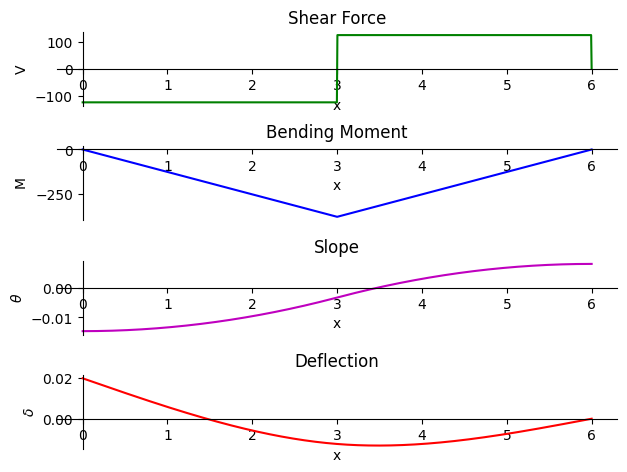

In [1]:
from sympy.physics.continuum_mechanics import Beam
from sympy import symbols

#Omschrijving van de balk
r0,r6 = symbols(['r0', 'r6'])
b = Beam(6, 5000, 10)
b.apply_load(r0, 0, -1)
b.apply_load(r6, 6, -1)
b.apply_load(-250, 3, -1)
b.bc_deflection = [(0,0.02), (6,0)]

#berekeningen
b.solve_for_reaction_loads(r0, r6)
print('belasting', b.load)
print('Dwarskrachten', b.shear_force())
print('Reactiekrachten', b.reaction_loads)
print('Moment',b.bending_moment())
print('Hoeverdraaiing',b.slope())
print('Doorbuiging',b.deflection())

#plots
axes = b.plot_loading_results()